In [2]:
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset, random_split
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

## Carga de datos de entrenamiento, división para obtener algunos de test y ampliación con transformaciones
En esta versión, **primero** se reconstruye cada imagen a tamaño **80x70**, **después** se aplican las transformaciones y **al final** se aplana para entrenar la red fully connected.


In [3]:
x_path = "X_train.npz"
y_path = "Y_train.npz"

def cargar_npz(ruta):
    data = np.load(ruta)
    
    # Si es un .npz, sacamos el primer array que contenga
    if isinstance(data, np.lib.npyio.NpzFile):
        if len(data.files) == 0:
            raise ValueError(f"El archivo {ruta} no contiene arrays")
        array = data[data.files[0]]
    else:
        array = data
    
    return array

try:
    X = cargar_npz(x_path)
    Y = cargar_npz(y_path)
except FileNotFoundError:
    raise ValueError("No se encuentran X_train.npz o Y_train.npz dentro de la carpeta datasets")
except Exception as e:
    raise ValueError(f"Error al cargar los datos: {e}")

print("Shape de X:", X.shape)
print("Shape de Y:", Y.shape)

Shape de X: (240, 5600)
Shape de Y: (240,)


In [4]:
# Pasar a tensores
X = torch.tensor(X, dtype=torch.float32)
Y = torch.tensor(Y, dtype=torch.long)

# Normalizar si son píxeles 0-255
X = X / 255.0

IMAGE_HEIGHT = 80
IMAGE_WIDTH = 70
IMAGE_SIZE = IMAGE_HEIGHT * IMAGE_WIDTH

def to_image_80x70(x):
    """Convierte una muestra en una imagen [1, 80, 70]."""
    if x.ndim == 1:
        if x.numel() != IMAGE_SIZE:
            raise ValueError(f"Se esperaban {IMAGE_SIZE} píxeles, pero llegaron {x.numel()}")
        return x.view(1, IMAGE_HEIGHT, IMAGE_WIDTH)

    if x.ndim == 2:
        if tuple(x.shape) != (IMAGE_HEIGHT, IMAGE_WIDTH):
            raise ValueError(f"Se esperaba una imagen de forma {(IMAGE_HEIGHT, IMAGE_WIDTH)}, pero llegó {tuple(x.shape)}")
        return x.unsqueeze(0)

    if x.ndim == 3:
        if tuple(x.shape) == (1, IMAGE_HEIGHT, IMAGE_WIDTH):
            return x
        raise ValueError(f"Se esperaba una imagen de forma {(1, IMAGE_HEIGHT, IMAGE_WIDTH)}, pero llegó {tuple(x.shape)}")

    raise ValueError(f"Forma de imagen no soportada: {tuple(x.shape)}")

def flatten_image(img):
    """Aplana una imagen [1, 80, 70] a un vector de 5600 componentes."""
    if tuple(img.shape) != (1, IMAGE_HEIGHT, IMAGE_WIDTH):
        raise ValueError(f"Se esperaba una imagen de forma {(1, IMAGE_HEIGHT, IMAGE_WIDTH)}, pero llegó {tuple(img.shape)}")
    return img.reshape(-1)

rotation_transform = transforms.RandomRotation((10, 10))
horizontal_flip_transform = transforms.RandomHorizontalFlip(p=1.0)

# Dataset base con entradas y etiquetas
dataset = TensorDataset(X, Y)


In [5]:
generator = torch.Generator().manual_seed(42)
train_dataset_base, test_dataset = random_split(dataset, [180, 60], generator=generator)

def augment_training_subset(subset):
    x_augmented = []
    y_augmented = []

    for x, y in subset:
        img = to_image_80x70(x)

        # Imagen original (ya montada en 80x70 y luego aplanada)
        x_augmented.append(flatten_image(img))
        y_augmented.append(y)

        # Nueva imagen rotada +10 grados
        rotated_img = rotation_transform(img)
        x_augmented.append(flatten_image(rotated_img))
        y_augmented.append(y)

        # Nueva imagen con espejo horizontal
        flipped_img = horizontal_flip_transform(img)
        x_augmented.append(flatten_image(flipped_img))
        y_augmented.append(y)

    return TensorDataset(torch.stack(x_augmented), torch.stack(y_augmented))

def flatten_subset(subset):
    x_flattened = []
    y_flattened = []

    for x, y in subset:
        img = to_image_80x70(x)
        x_flattened.append(flatten_image(img))
        y_flattened.append(y)

    return TensorDataset(torch.stack(x_flattened), torch.stack(y_flattened))

train_dataset = augment_training_subset(train_dataset_base)
test_dataset = flatten_subset(test_dataset)

N_training = len(train_dataset)
N_test = len(test_dataset)

print("Total original:", len(dataset))
print("Train original:", len(train_dataset_base))
print("Train con augmentación:", len(train_dataset))
print("Test:", len(test_dataset))


Total original: 240
Train original: 180
Train con augmentación: 540
Test: 60


## Visualización de algunas imágenes tras las transformaciones
Ejecuta esta celda para comparar imágenes del conjunto de entrenamiento **ya reconstruidas a 80x70** con sus versiones rotadas y espejadas.


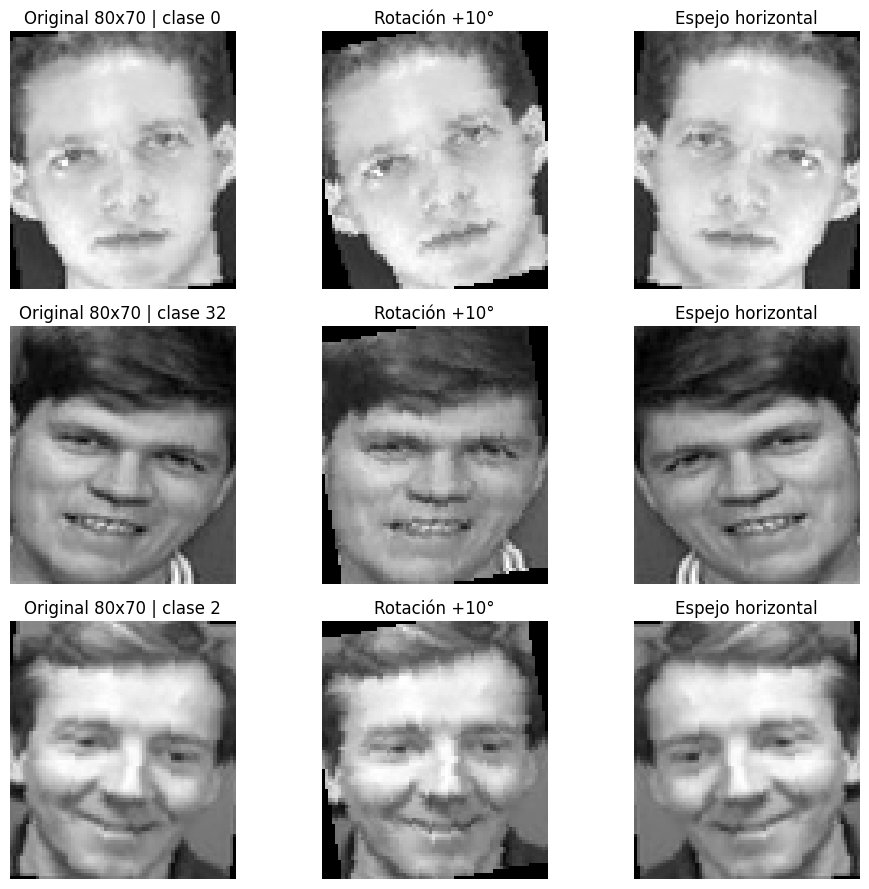

In [6]:
# Visualización de ejemplos de augmentación
num_examples = 3  # puedes cambiarlo si quieres ver más o menos ejemplos
indices = torch.randperm(len(train_dataset_base))[:num_examples]

fig, axes = plt.subplots(num_examples, 3, figsize=(10, 3 * num_examples))

if num_examples == 1:
    axes = np.expand_dims(axes, axis=0)

for row, idx in enumerate(indices):
    x, y = train_dataset_base[idx]
    img = to_image_80x70(x)

    original_img = img.squeeze(0).cpu().numpy()
    rotated_img = rotation_transform(img).squeeze(0).cpu().numpy()
    flipped_img = horizontal_flip_transform(img).squeeze(0).cpu().numpy()

    images = [original_img, rotated_img, flipped_img]
    titles = [f"Original 80x70 | clase {int(y)}", "Rotación +10°", "Espejo horizontal"]

    for col, (image, title) in enumerate(zip(images, titles)):
        axes[row, col].imshow(image, cmap="gray")
        axes[row, col].set_title(title)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()


Definimos la funcion metric para medir el rendimiento de nuestro modelo

In [7]:
def linear_link(x):
    return x

class FCLayer(nn.Module):
    def __init__(self, dim_in, dim_out, act, drop, batch_norm, add_residual):
        super().__init__()
        ## create parameters
        self.linear = nn.Linear(dim_in, dim_out)
        self.act = act
        self.drop = nn.Dropout(p = drop)
        if batch_norm:
            self.bn = nn.BatchNorm1d(dim_out)
        else:
            self.bn = linear_link

        self.add_residual = add_residual
        # when residual is needed we need to readapt input
        if add_residual and dim_in != dim_out:
            self.bottleneck = nn.Linear(dim_in,dim_out)
        else:
            self.bottleneck = linear_link

        self.traced_grads = {}

    def forward(self, x):
        fx = self.drop(self.act(self.bn(self.linear(x))))
        if self.add_residual:
            fx = self.bottleneck(x) + fx
        return fx

    def trace_gradients(self):
        for k, v in self.named_parameters():
            if k in self.traced_grads.keys():
                self.traced_grads[k].append( v.grad.data.clone() )
            else:
                self.traced_grads[k] = [v.grad.data.clone()]

    def reset_traced_grads(self):
        self.traced_grads = {}

    def get_traced_grads(self):
        return self.traced_grads

class FCDNN(nn.Module):
    def __init__(self, dim_in, dim_out, neurons_hidden : list, hidden_activations:list, dropout_hidden, batch_norm: bool, add_residual:bool, link_function, loss_function):
        super().__init__()

        assert len(neurons_hidden) == len(hidden_activations), "List specifying hidden activations and number of hidden layers must coincide"
        assert len(neurons_hidden) == len(dropout_hidden), "List specifying hidden activations and dropout per layer"


        module_list = nn.ModuleList([])

        # input layer hidden layers
        for num_neur, act, drop in zip(neurons_hidden, hidden_activations, dropout_hidden):
            module_list.append(FCLayer(dim_in, num_neur, act, drop, batch_norm, add_residual))
            dim_in = num_neur

        # output layer
        o_layer = FCLayer(dim_in, dim_out, act = linear_link, drop = 0.0, batch_norm = False, add_residual = False)
        module_list.append(o_layer)

        self.layers = module_list

        ## Loss and link function
        self.link = link_function
        self.loss = loss_function

    def forward_train(self,x, apply_link):
        self.train()

        for l in self.layers:
            x = l(x)
        y = x
        if apply_link:
            y = self.link(y)

        return y

    def forward_eval(self,x, apply_link):
        self.eval()

        for l in self.layers:
            x = l(x)
        y = x
        if apply_link:
            y = self.link(y)

        return y

    def compute_loss(self,t,y):
        return self.loss(y,t)

    def get_internal_representations(self, x, apply_link):
        internals = {}
        # exclude output layer projection since this method gets internal representations
        for i, l in enumerate(self.layers[:-1]):
            x = l(x)
            internals[f'layer {i+1}']= x
        return internals

    def trace_gradients(self):
        for l in self.layers:
            l.trace_gradients()

    def reset_traced_grads(self):
        for l in self.layers:
            l.reset_traced_grads()

    def get_traced_grads(self):
        traced_grads = {}
        for i,l in enumerate(self.layers):
            traced_grads[f'layer {i+1}'] = l.get_traced_grads()

        return traced_grads

In [8]:
def compute_metric(dataloader, model):
    acc = 0
    tot_samples = 0

    model.eval()
    with torch.no_grad():
        for x, t in dataloader:
            x, t = x.to(device), t.to(device)
            y = model.forward_eval(x, apply_link=False)

            acc += (t == torch.argmax(y, dim=1)).sum().item()
            tot_samples += len(t)

    return acc / tot_samples


def compute_metric_top3(dataloader, model, k=3):
    acc = compute_metric(dataloader, model)

    top_k_acc = 0
    tot_samples = 0

    model.eval()
    with torch.no_grad():
        for x, t in dataloader:
            x, t = x.to(device), t.to(device)
            y = model.forward_eval(x, apply_link=False)

            top_k_preds = torch.topk(y, k=k, dim=1).indices
            top_k_acc += top_k_preds.eq(t.view(-1, 1)).any(dim=1).sum().item()
            tot_samples += len(t)

    top_k_acc = top_k_acc / tot_samples
    global_metric = 0.7 * acc + 0.3 * top_k_acc

    return acc, top_k_acc, global_metric

In [9]:
def test_model(
    model : torch.nn.Module,
    epochs : int,
    train_batch_size : int,
    lr : float,
    betas : tuple,
    eps : float,
    mode : str,
    weight_decay : float,
    factor : float,
    patience : int,
    min_lr : float,
    mmu : float,
    apply_scheduler : bool,
    eval_each : int,
    train_dataset : torchvision.datasets,
    test_dataset : torchvision.datasets
):
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=train_batch_size, shuffle=True)
    train_loader_eval = torch.utils.data.DataLoader(train_dataset, batch_size=train_batch_size, shuffle=False)
    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=train_batch_size, shuffle=False)

    loss_epochs = []
    train_acc_epochs = []
    test_acc_epochs = []
    train_top3_epochs = []
    test_top3_epochs = []
    train_global_epochs = []
    test_global_epochs = []

    with torch.no_grad():
        loss_acc = 0.0
        for batch_idx, (x, t) in enumerate(train_loader_eval):
            x, t = x.to(device), t.to(device)

            y = model.forward_train(x, apply_link=False)
            L = model.compute_loss(t, y)
            loss_acc += len(x) * L.item()

        train_acc, train_top3, train_global = compute_metric_top3(train_loader_eval, model, k=3)
        test_acc, test_top3, test_global = compute_metric_top3(test_loader, model, k=3)

    loss_epochs.append(loss_acc / N_training)
    train_acc_epochs.append(train_acc)
    test_acc_epochs.append(test_acc)
    train_top3_epochs.append(train_top3)
    test_top3_epochs.append(test_top3)
    train_global_epochs.append(train_global)
    test_global_epochs.append(test_global)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        betas=betas,
        eps=eps,
        weight_decay=weight_decay
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode=mode,
        factor=factor,
        patience=patience,
        min_lr=min_lr
    )

    for e in range(epochs):
        model.train()
        loss_acc = 0.0

        for batch_idx, (x, t) in enumerate(train_loader):
            x, t = x.to(device), t.to(device)

            y = model.forward_train(x, apply_link=False)
            L = model.compute_loss(t, y)
            loss_acc += len(x) * L.item()

            L.backward()
            optimizer.step()
            optimizer.zero_grad()

            print(f"On epoch {e+1} batch_idx {batch_idx + 1} got loss {L.item():.5f}", end="\r")

        if (e + 1) % eval_each == 0 or e == 0:
            with torch.no_grad():
                train_acc, train_top3, train_global = compute_metric_top3(train_loader_eval, model, k=3)
                test_acc, test_top3, test_global = compute_metric_top3(test_loader, model, k=3)

            if apply_scheduler:
                scheduler.step(test_global)

            print(" " * 300, end="\r")
            print(
                f"On epoch {e+1} got loss {loss_acc/N_training:.5f} "
                f"with train accuracy {train_acc:.5f}, train top3 {train_top3:.5f}, train global {train_global:.5f} "
                f"and test accuracy {test_acc:.5f}, test top3 {test_top3:.5f}, test global {test_global:.5f}"
            )
        else:
            print(" " * 300, end="\r")
            print(f"On epoch {e+1} got loss {loss_acc/N_training:.5f}")

        loss_epochs.append(loss_acc / N_training)
        train_acc_epochs.append(train_acc)
        test_acc_epochs.append(test_acc)
        train_top3_epochs.append(train_top3)
        test_top3_epochs.append(test_top3)
        train_global_epochs.append(train_global)
        test_global_epochs.append(test_global)

    return (
        loss_epochs,
        train_acc_epochs,
        test_acc_epochs,
        train_top3_epochs,
        test_top3_epochs,
        train_global_epochs,
        test_global_epochs
    )

Best Model

In [ ]:
torch.manual_seed(0)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Usando:", device)

## ============== ##
## Model Creation ##
## ============== ##
dim_in = 5600
dim_out = 40
num_h = 3
neu_h = 256
model = FCDNN(
              dim_in = dim_in,
              dim_out = dim_out,
              neurons_hidden = [256,256,256], #[neu_h] * num_h,
              hidden_activations = [torch.relu] * num_h,
              dropout_hidden = [0.5, 0.5, 0.5], #* num_h,
              batch_norm = True,
              add_residual = False,
              link_function = torch.softmax,
              loss_function = nn.CrossEntropyLoss(),
             )
model.to(device)


three_drop05_loss, three_drop05_train_acc, three_drop05_test_acc, three_drop05_train_top3, three_drop05_test_top3, three_drop05_train_global, three_drop05_test_global = test_model(
        model,
        epochs = 1000,
        lr = 3e-4,
        betas=(0.9, 0.95),
        eps=1e-08,
        weight_decay = 1e-3,
        mmu = 0.8,
        train_batch_size = 90,
        apply_scheduler = True,
        mode = 'max',
        factor = 0.5,
        patience = 20,
        min_lr = 1e-4,
        eval_each = 1,
        train_dataset = train_dataset,
        test_dataset = test_dataset
)

Usando: cuda
On epoch 1 got loss 3.70898 with train accuracy 0.14074, train top3 0.24815, train global 0.17296 and test accuracy 0.05000, test top3 0.13333, test global 0.07500                                                                                                                                         
On epoch 2 got loss 2.51589 with train accuracy 0.03889, train top3 0.37407, train global 0.13944 and test accuracy 0.01667, test top3 0.23333, test global 0.08167                                                                                                                                         
On epoch 3 got loss 1.87707 with train accuracy 0.19444, train top3 0.46667, train global 0.27611 and test accuracy 0.11667, test top3 0.21667, test global 0.14667                                                                                                                                         
On epoch 4 got loss 1.46418 with train accuracy 0.58148, train top3 0.82778, train g

In [11]:
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

n_test = len(test_dataset)
n_clases = 40

matriz_probs = torch.zeros((n_test, n_clases))
#matriz_probs_np = matriz_probs.numpy()   VERSION DE NUMPY, SI SE QUIERE USAR EN LUGAR DE TENSOR
#np.save("matriz_probs_test.npy", matriz_probs_np)   SIRVE PARA GUARDAR LA MATRIZ EN UN ARCHIVO .npy SI SE QUIERE USAR NUMPY EN LUGAR DE TENSOR

model.eval()

indice = 0
with torch.no_grad():
    for x, _ in test_loader:
        x = x.to(device)

        logits = model.forward_eval(x, apply_link=False)

        probs = torch.softmax(logits, dim=1).cpu()

        batch_size = probs.shape[0]
        matriz_probs[indice:indice + batch_size, :] = probs
        indice += batch_size

print(matriz_probs.shape)
print(matriz_probs)

torch.Size([60, 40])
tensor([[2.0459e-15, 5.9202e-10, 3.4921e-18,  ..., 1.3724e-23, 9.6130e-14,
         3.3653e-20],
        [5.9168e-15, 1.1592e-10, 4.2937e-20,  ..., 3.1506e-25, 2.3514e-13,
         7.9818e-23],
        [3.9298e-12, 1.7451e-12, 8.8398e-09,  ..., 9.8298e-01, 1.1222e-10,
         7.6819e-10],
        ...,
        [1.1265e-09, 1.0124e-13, 8.5706e-13,  ..., 1.7699e-08, 1.0230e-11,
         1.4458e-10],
        [4.9315e-09, 5.7862e-09, 1.0925e-10,  ..., 1.1705e-08, 6.2223e-12,
         2.2073e-10],
        [6.3109e-03, 1.7130e-06, 7.1693e-08,  ..., 6.3133e-09, 2.0646e-09,
         1.6703e-11]])


In [12]:
best_epoch = np.argmax(three_drop05_test_acc)
best_test_acc = three_drop05_test_acc[best_epoch]
best_train_acc = three_drop05_train_acc[best_epoch]
best_loss = three_drop05_loss[best_epoch]


print(f"Mejor época: {best_epoch}")
print(f"Mejor test accuracy: {best_test_acc:.4f}")
print(f"Mejor test top3: {three_drop05_test_top3[best_epoch]:.4f}")
print(f"Mejor test global: {three_drop05_test_global[best_epoch]:.4f}")
print(f"Train accuracy en esa época: {best_train_acc:.4f}")
print(f"Train top3 en esa época: {three_drop05_train_top3[best_epoch]:.4f}")
print(f"Train global en esa época: {three_drop05_train_global[best_epoch]:.4f}")
print(f"Loss en esa época: {best_loss:.4f}")


Mejor época: 50
Mejor test accuracy: 0.8667
Mejor test top3: 0.9000
Mejor test global: 0.8767
Train accuracy en esa época: 1.0000
Train top3 en esa época: 1.0000
Train global en esa época: 1.0000
Loss en esa época: 0.0019


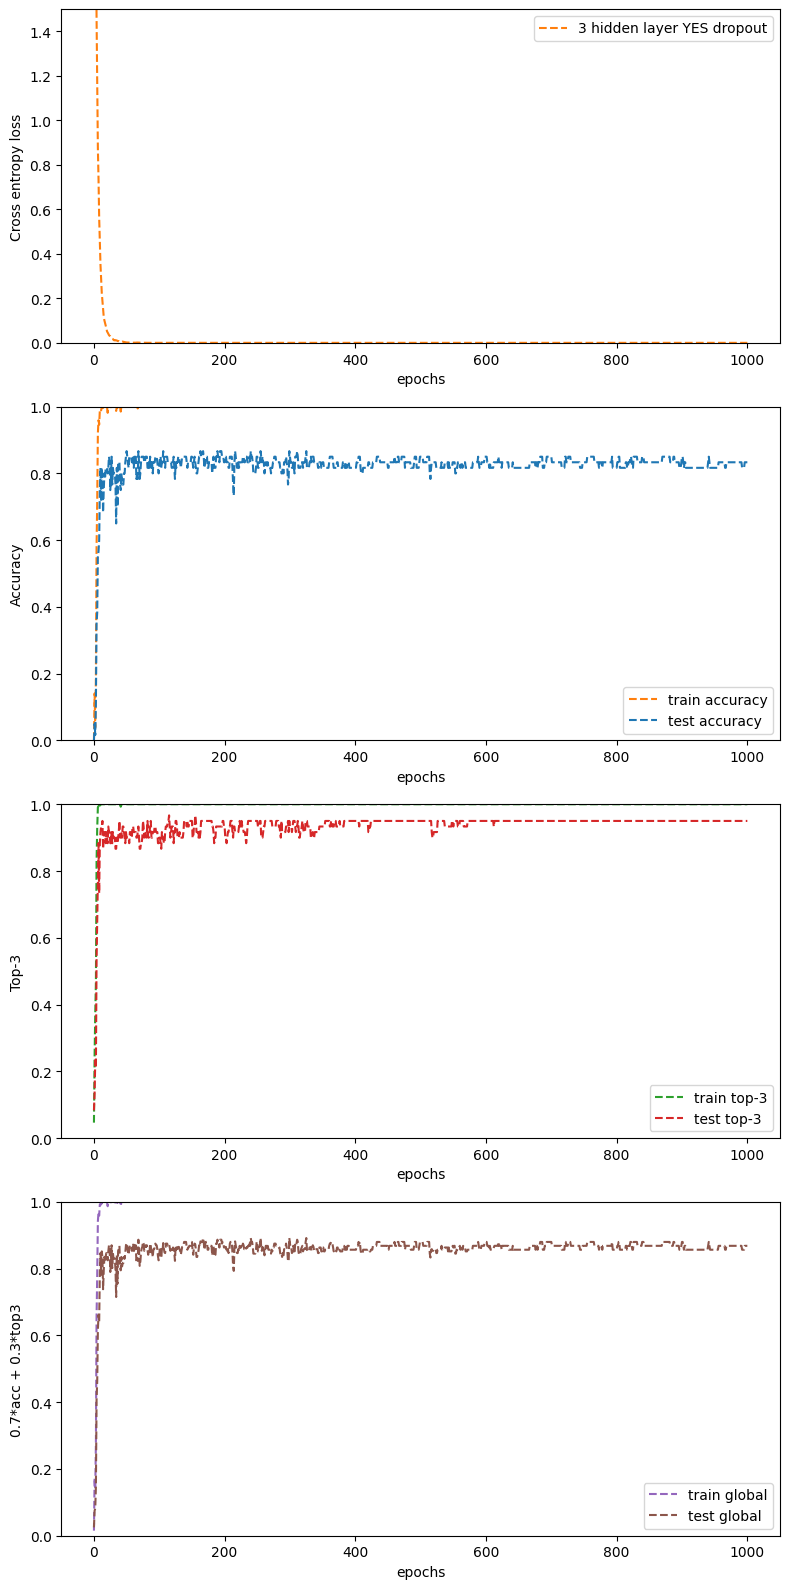

In [13]:
fig, (ax11, ax21, ax31, ax41) = plt.subplots(4, 1, figsize=(8, 16))

## Plot cross entropy loss
ax11.plot(range(len(three_drop05_loss)), three_drop05_loss,
          label='3 hidden layer YES dropout', color='C1', linestyle='--')
ax11.set_ylim([0.0, 1.5])
ax11.set_ylabel('Cross entropy loss')
ax11.set_xlabel('epochs')
ax11.legend()

## Plot accuracy (train y test)
ax21.plot(range(len(three_drop05_train_acc)), three_drop05_train_acc,
          label='train accuracy', color='C1', linestyle='--')
ax21.plot(range(len(three_drop05_test_acc)), three_drop05_test_acc,
          label='test accuracy', color='C0', linestyle='--')
ax21.set_ylim([0.0, 1.0])
ax21.set_ylabel('Accuracy')
ax21.set_xlabel('epochs')
ax21.legend()

## Plot top-3 (train y test)
ax31.plot(range(len(three_drop05_train_top3)), three_drop05_train_top3,
          label='train top-3', color='C2', linestyle='--')
ax31.plot(range(len(three_drop05_test_top3)), three_drop05_test_top3,
          label='test top-3', color='C3', linestyle='--')
ax31.set_ylim([0.0, 1.0])
ax31.set_ylabel('Top-3')
ax31.set_xlabel('epochs')
ax31.legend()

## Plot global metric (train y test)
ax41.plot(range(len(three_drop05_train_global)), three_drop05_train_global,
          label='train global', color='C4', linestyle='--')
ax41.plot(range(len(three_drop05_test_global)), three_drop05_test_global,
          label='test global', color='C5', linestyle='--')
ax41.set_ylim([0.0, 1.0])
ax41.set_ylabel('0.7*acc + 0.3*top3')
ax41.set_xlabel('epochs')
ax41.legend()

plt.tight_layout()
plt.show()